# JFK archived forecast evaluation

**Preliminary descriptive results — no model winner or calibration claim.** Actual archived NWS, NOAA GEFS (`gfs025`) and ECMWF IFS ENS (`ecmwf_ifs025`, both via Open-Meteo) forecasts only. This notebook makes no network requests and does not modify the history notebook or forecast archive.

Hourly temperature is verified against screened JFK METAR reports. Daily extrema, midpoint, HDD65 and CDD65 are a **separate evaluation** against GHCN. Daily forecast extrema are **hourly-sampled proxies**, which can miss true extrema.

See [EVALUATION.md](EVALUATION.md) for timing evidence, data contracts, exclusions, formulas and reproduction commands. Test fixtures never enter these results.

In [1]:
from pathlib import Path
from unittest.mock import patch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
import forecast_evaluation as ev

# Explicit, pinned evaluation vintage. Change these parameters for a new evaluation.
config = ev.Config(as_of='2026-09-21T00:30:00Z', start='2026-09-17T00:00:00Z',
                   cutoff_hours=(0, 6, 12, 18), tolerance_minutes=15,
                   max_age_hours=24, persistence_max_age_hours=6)
# Fail if an accidental network request is introduced into the offline path.
with patch('requests.sessions.Session.request', side_effect=AssertionError('Offline evaluation')):
    result = ev.evaluate(config=config)
ev.write_results(result, Path('data/evaluation'))
display(pd.Series(result['config'], name='configuration').to_frame())
print(ev.verify_result(result))
plt.rcParams.update({'figure.dpi': 120, 'axes.spines.top': False, 'axes.spines.right': False})
labels = {'nws': 'NWS', 'gfs025': 'GEFS', 'ecmwf_ifs025': 'ECMWF'}


/Users/stevenxu/Documents/ChatGPT/Weather Derivative/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


,configuration
as_of,2026-09-21T00:30:00Z
start,2026-09-17T00:00:00Z
cutoff_hours,"(0, 6, 12, 18)"
tolerance_minutes,15
max_age_hours,24
persistence_max_age_hours,6
degree_day_base_f,65


{'scored_rows': 2586, 'invariants': 'passed'}


## Timing and selection

At each 00/06/12/18 UTC cutoff, select the most recently first-retrieved distinct content, no more than 24 hours old. Identical downloads do not refresh its age or add score rows. Forecast lead is target minus that actual first retrieval; initialization is unverified. Targets at or before the cutoff are excluded.

Open-Meteo temperature is instantaneous; its hourly values may be interpolated. NWS supplies one-hour periods; this evaluation explicitly uses their **start** as the representative point time, not an hourly-average observation. METAR uses `obsTime`, not `reportTime`. Nearest screened report within ±15 minutes wins (earlier on a tie). Signed observation-minus-target offsets are retained; no interpolation or gap filling occurs.

Outcomes may arrive after forecast issuance, but must be archived by the evaluation as-of. Persistence inputs must already have been retrieved and observed by their cutoff, and be at most 6 hours old. Basic METAR screening checks station, timestamps, finite plausible temperature, dewpoint consistency and agreement with the raw report. Opaque `qcField` values are preserved, not treated as a documented temperature QC flag.

## Archive and matching coverage

In [2]:
receipts, snapshots = result['forecast_receipts'], result['forecast_snapshots']
archive_coverage = receipts.groupby('model').agg(receipts=('snapshot_id','size'), snapshots=('snapshot_id','nunique'),
    first_retrieval=('retrieval_time','min'), last_retrieval=('retrieval_time','max'))
display(archive_coverage)
coverage = result['coverage']
hourly_coverage = coverage[coverage.quantity.eq('hourly_temperature_c')]
display(hourly_coverage)
print('METAR observation range:', result['metar_as_of'].observation_time.min(), 'to', result['metar_as_of'].observation_time.max())
display(result['metar_as_of'].quality_status.value_counts().rename_axis('quality_status').to_frame('reports'))
print('Latest accepted GHCN date:', result['ghcn_as_of'].loc[result['ghcn_as_of'].valid_day, 'date'].max())
print('Counts are cutoff–target pairs. Hours recur across cutoffs; members are scenarios, not extra observations.')

,receipts,snapshots,first_retrieval,last_retrieval
model,,,,
ecmwf_ifs025,8,5,2026-09-17 21:50:30.221473+00:00,2026-09-21 00:17:01.697152+00:00
gfs025,8,5,2026-09-17 21:50:27.977707+00:00,2026-09-21 00:16:59.736173+00:00
nws,10,7,2026-09-17 21:00:10.787225+00:00,2026-09-21 00:16:57.691635+00:00


,model,statistic,quantity,candidate_targets,matched_targets,unique_target_dates,forecast_snapshots,unique_target_times,scored_cutoffs,matched_start,matched_end
2,ecmwf_ifs025,mean,hourly_temperature_c,4320,420,4,4,72,11,2026-09-18 01:00:00+00:00,2026-09-21 00:00:00+00:00
8,ecmwf_ifs025,median,hourly_temperature_c,4320,420,4,4,72,11,2026-09-18 01:00:00+00:00,2026-09-21 00:00:00+00:00
14,gfs025,mean,hourly_temperature_c,2880,420,4,4,72,11,2026-09-18 01:00:00+00:00,2026-09-21 00:00:00+00:00
20,gfs025,median,hourly_temperature_c,2880,420,4,4,72,11,2026-09-18 01:00:00+00:00,2026-09-21 00:00:00+00:00
26,nws,deterministic,hourly_temperature_c,1872,420,4,4,72,11,2026-09-18 01:00:00+00:00,2026-09-21 00:00:00+00:00
30,persistence_for_ecmwf_ifs025,persistence,hourly_temperature_c,4320,162,4,4,72,4,2026-09-18 01:00:00+00:00,2026-09-21 00:00:00+00:00
31,persistence_for_gfs025,persistence,hourly_temperature_c,2880,162,4,4,72,4,2026-09-18 01:00:00+00:00,2026-09-21 00:00:00+00:00
32,persistence_for_nws,persistence,hourly_temperature_c,1872,162,4,4,72,4,2026-09-18 01:00:00+00:00,2026-09-21 00:00:00+00:00


METAR observation range: 2026-08-18 21:51:00+00:00 to 2026-09-20 23:51:00+00:00


,reports
quality_status,
basic_screen_pass,852


Latest accepted GHCN date: 2026-09-17 00:00:00
Counts are cutoff–target pairs. Hours recur across cutoffs; members are scenarios, not extra observations.


In [3]:
display(result['selection'].groupby(['model','reason']).size().unstack(fill_value=0))
exclusions = result['exclusion_counts']
display(exclusions[(exclusions.scope == 'target') & exclusions.statistic.isin(['mean','deterministic'])]
        .pivot_table(index=['quantity','reason'], columns='model', values='count', fill_value=0))
if not result['archive_exclusions'].empty:
    display(result['archive_exclusions'])
print('Exclusion reasons can overlap. Future archive targets remain visible but are never scored.')
h = result['hourly_members']
print('Matching offset minutes (unique verified cutoff–target pairs):')
display(h[h.error.notna()].drop_duplicates(['model','cutoff','target_time'])
        .groupby('model').time_offset_minutes.agg(['min','median','max']))

reason,no_snapshot_by_cutoff,selected,stale_forecast
model,,,
ecmwf_ifs025,4,12,1
gfs025,4,12,1
nws,4,12,1


model                                             ecmwf_ifs025  gfs025     nws
quantity             reason                                                   
cdd_proxy_f_days     day_not_finished_as_of              164.0   104.0    72.0
                     day_started_by_cutoff                27.0    27.0    21.0
                     incomplete_day                       24.0    24.0    24.0
                     invalid_forecast                      0.0     0.0    24.0
                     missing_members                      24.0    24.0     0.0
                     missing_observation                 188.0   128.0    90.0
hdd_proxy_f_days     day_not_finished_as_of              164.0   104.0    72.0
                     day_started_by_cutoff                27.0    27.0    21.0
                     incomplete_day                       24.0    24.0    24.0
                     invalid_forecast                      0.0     0.0    24.0
                     missing_members                      24.0    24.0     0.0
                     missing_observation                 188.0   128.0    90.0
hourly_temperature_c invalid_forecast                     54.0    18.0     0.0
                     missing_members                      54.0    18.0     0.0
                     missing_observation                3636.0  2196.0  1308.0
                     target_after_as_of                 3636.0  2196.0  1308.0
                     target_not_future_at_cutoff         264.0   264.0   144.0
midpoint_proxy_c     day_not_finished_as_of              164.0   104.0    72.0
                     day_started_by_cutoff                27.0    27.0    21.0
                     incomplete_day                       24.0    24.0    24.0
                     invalid_forecast                      0.0     0.0    24.0
                     missing_members                      24.0    24.0     0.0
                     missing_observation                 188.0   128.0    90.0
tmax_proxy_c         day_not_finished_as_of              164.0   104.0    72.0
                     day_started_by_cutoff                27.0    27.0    21.0
                     incomplete_day                       24.0    24.0    24.0
                     invalid_forecast                      0.0     0.0    24.0
                     missing_members                      24.0    24.0     0.0
                     missing_observation                 188.0   128.0    90.0
tmin_proxy_c         day_not_finished_as_of              164.0   104.0    72.0
                     day_started_by_cutoff                27.0    27.0    21.0
                     incomplete_day                       24.0    24.0    24.0
                     invalid_forecast                      0.0     0.0    24.0
                     missing_members                      24.0    24.0     0.0
                     missing_observation                 188.0   128.0    90.0

Exclusion reasons can overlap. Future archive targets remain visible but are never scored.
Matching offset minutes (unique verified cutoff–target pairs):


,min,median,max
model,,,
ecmwf_ifs025,-9.0,-9.0,3.0
gfs025,-9.0,-9.0,3.0
nws,-9.0,-9.0,3.0


## Forecast versus observed hourly temperature
The following panels use one common archived issuance cutoff. Bands are empirical member percentiles, not calibrated confidence intervals.

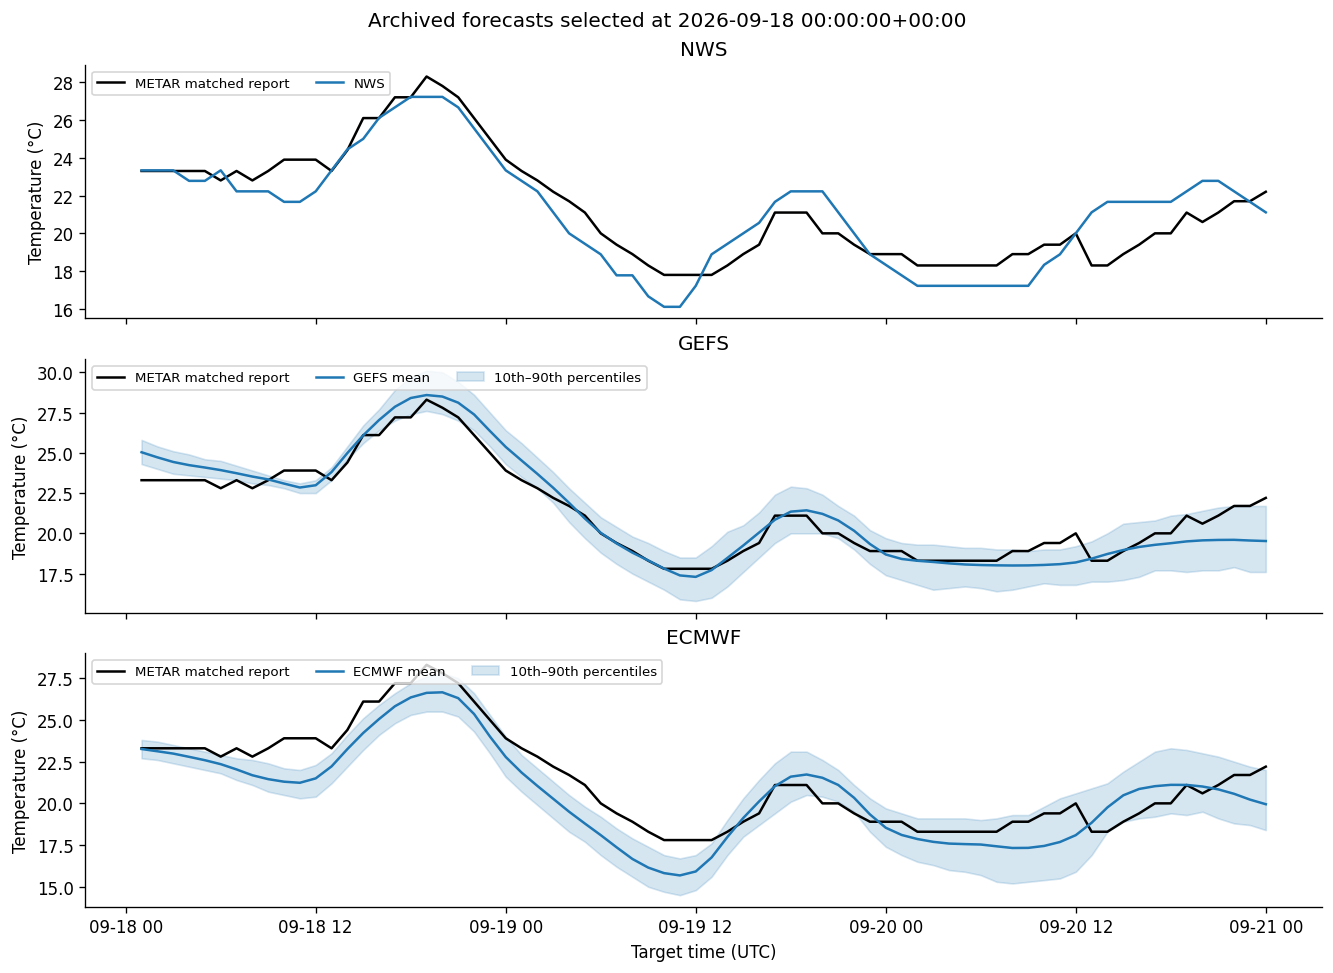

In [4]:
scores = result['scores']
good = scores[(scores.quantity == 'hourly_temperature_c') & scores.error.notna() & scores.model.isin(ev.MODELS)]
if len(good):
    common_cutoff = good.cutoff.min()
    fig, axes = plt.subplots(3, 1, figsize=(11, 8), sharex=True, constrained_layout=True)
    for ax, model in zip(axes, ev.MODELS):
        f = good[(good.model == model) & (good.cutoff == common_cutoff) &
                 good.statistic.isin(['mean','deterministic'])].sort_values('target_time')
        ax.plot(f.target_time, f.observation, color='black', label='METAR matched report', linewidth=1.5)
        ax.plot(f.target_time, f.forecast, label=labels[model] + (' mean' if model != 'nws' else ''), color='tab:blue')
        if model != 'nws':
            ax.fill_between(f.target_time, f.p10, f.p90, color='tab:blue', alpha=.18, label='10th–90th percentiles')
        ax.set_ylabel('Temperature (°C)'); ax.set_title(labels[model]); ax.legend(loc='upper left', fontsize=8, ncol=3)
    axes[-1].set_xlabel('Target time (UTC)')
    fig.suptitle(f'Archived forecasts selected at {common_cutoff}')
    plt.show()
else:
    print('Unsupported: no matched hourly forecasts.')

## Error by lead time

Bias is forecast minus observation. MAE and RMSE are in °C. Individual coverage uses retrieval-based lead bins. **Common-target comparisons use the same cutoff, target and cutoff-relative lead bin for every model**, because different retrieval ages would otherwise put the same target in different bins. The full common table includes ensemble medians as well as means; the plot shows means and NWS for readability. Empty bins have no result, not zero error. Sparse bins are descriptive only.

**Current sample limitation:** the common 3–5d bin contains only one target; individual retrieval-based 3–5d bins contain just three distinct hours on one date. Comparisons in these bins are unsupported. Five-day and longer horizons have no matched outcomes. All shorter-range results are preliminary.

,model,statistic,quantity,lead_bin,matched_targets,unique_target_dates,forecast_snapshots,cutoffs,unique_target_times,bias,mae,rmse,crps,interval_coverage,interval_width
0,ecmwf_ifs025,mean,hourly_temperature_c,0–24h,220,4,4,11,72,-0.685,1.185,1.346,0.851,0.445,2.036
1,ecmwf_ifs025,mean,hourly_temperature_c,24–48h,136,3,3,8,49,-0.232,1.118,1.298,0.772,0.647,2.761
2,ecmwf_ifs025,mean,hourly_temperature_c,48–72h,63,2,1,4,25,-0.320,1.092,1.251,0.719,0.952,3.660
3,ecmwf_ifs025,mean,hourly_temperature_c,3–5d,1,1,1,1,1,-2.251,2.251,2.251,1.439,0.000,3.600
4,ecmwf_ifs025,median,hourly_temperature_c,0–24h,220,4,4,11,72,-0.666,1.184,1.342,0.851,0.445,2.036
5,ecmwf_ifs025,median,hourly_temperature_c,24–48h,136,3,3,8,49,-0.192,1.118,1.315,0.772,0.647,2.761
6,ecmwf_ifs025,median,hourly_temperature_c,48–72h,63,2,1,4,25,-0.287,1.097,1.267,0.719,0.952,3.660
7,ecmwf_ifs025,median,hourly_temperature_c,3–5d,1,1,1,1,1,-2.400,2.400,2.400,1.439,0.000,3.600
8,gfs025,mean,hourly_temperature_c,0–24h,220,4,4,11,72,0.222,0.580,0.712,0.433,0.723,1.800
9,gfs025,mean,hourly_temperature_c,24–48h,136,3,3,8,49,-0.125,0.537,0.694,0.420,0.904,2.510


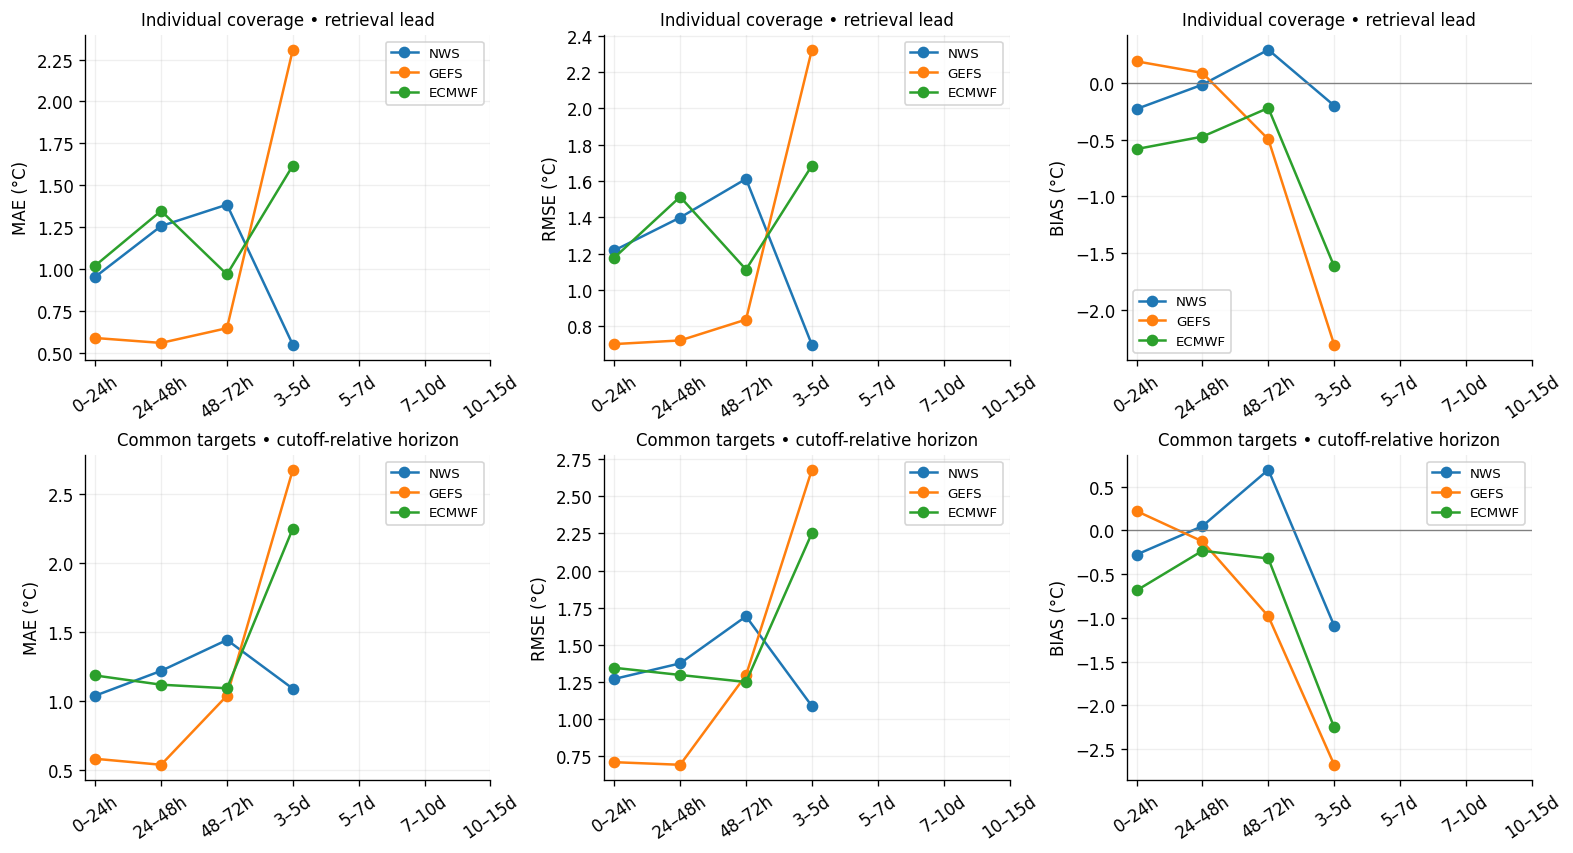

In [5]:
display(result['metrics_common'].round(3))
fig, axes = plt.subplots(2, 3, figsize=(13, 7), constrained_layout=True)
for row, (table_name, lead_label) in enumerate([
        ('metrics_individual', 'Individual coverage • retrieval lead'),
        ('metrics_common', 'Common targets • cutoff-relative horizon')]):
    table = result[table_name]
    for ax, metric in zip(axes[row], ['mae','rmse','bias']):
        for model in ev.MODELS:
            f = table[(table.model == model) & (table.quantity == 'hourly_temperature_c') &
                      table.statistic.isin(['mean','deterministic'])].set_index('lead_bin').reindex(ev.LABELS[:-1])
            ax.plot(range(len(f)), f[metric], marker='o', label=labels[model])
        ax.set_xticks(range(7), ev.LABELS[:-1], rotation=35)
        ax.set_ylabel(metric.upper() + ' (°C)'); ax.set_title(lead_label, fontsize=10)
        if metric == 'bias': ax.axhline(0, color='gray', linewidth=.8)
        ax.grid(alpha=.2); ax.legend(fontsize=8)
plt.show()

## Ensemble distribution diagnostics

CRPS = mean absolute member error − half the mean absolute pairwise member difference (including diagonal pairs). An exact expected set of 31 GEFS or 51 ECMWF IDs and finite values is required, including the control. Quantiles use linear interpolation. Empirical coverage is the fraction of outcomes in the inclusive 10th–90th percentile band. **Nominal 80% does not mean calibrated 80% coverage.** These few dependent days cannot establish calibration; wider bands can increase coverage without increasing forecast usefulness.

The apparent 0% coverage at 3–5d is a single missed outcome, not an estimate of that horizon’s calibration.

,model,lead_bin,matched_targets,unique_target_dates,crps,interval_coverage,interval_width
0,ecmwf_ifs025,0–24h,220,4,0.851,0.445,2.036
1,ecmwf_ifs025,24–48h,136,3,0.772,0.647,2.761
2,ecmwf_ifs025,48–72h,63,2,0.719,0.952,3.660
3,ecmwf_ifs025,3–5d,1,1,1.439,0.000,3.600
8,gfs025,0–24h,220,4,0.433,0.723,1.800
9,gfs025,24–48h,136,3,0.420,0.904,2.510
10,gfs025,48–72h,63,2,0.694,0.841,3.160
11,gfs025,3–5d,1,1,1.779,0.000,4.100


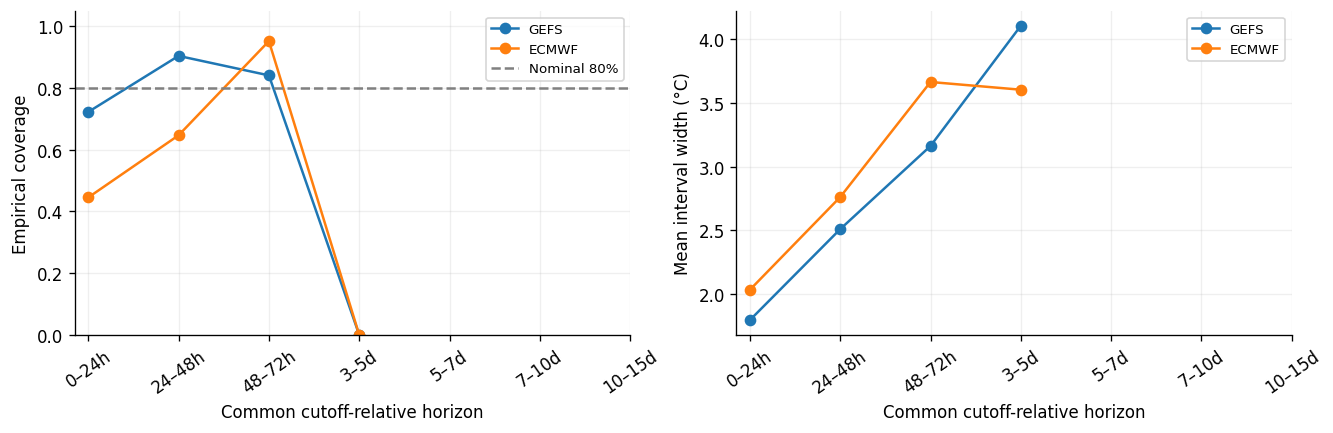

In [6]:
prob = result['metrics_common']
prob = prob[(prob.statistic == 'mean') & (prob.quantity == 'hourly_temperature_c')]
display(prob[['model','lead_bin','matched_targets','unique_target_dates','crps','interval_coverage','interval_width']].round(3))
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5), constrained_layout=True)
for model in ['gfs025','ecmwf_ifs025']:
    f = prob[prob.model == model].set_index('lead_bin').reindex(ev.LABELS[:-1])
    axes[0].plot(range(7), f.interval_coverage, marker='o', label=labels[model])
    axes[1].plot(range(7), f.interval_width, marker='o', label=labels[model])
axes[0].axhline(.8, color='gray', linestyle='--', label='Nominal 80%')
axes[0].set_ylim(0, 1.05); axes[0].set_ylabel('Empirical coverage')
axes[1].set_ylabel('Mean interval width (°C)')
for ax in axes:
    ax.set_xticks(range(7), ev.LABELS[:-1], rotation=35)
    ax.set_xlabel('Common cutoff-relative horizon'); ax.legend(fontsize=8); ax.grid(alpha=.2)
plt.show()

## Persistence on eligible paired targets

This baseline holds the latest available screened METAR temperature constant. Each `persistence_for_...` series is paired to that model; the model rows below are restricted to the same eligible baseline targets. These counts can be much smaller than the main evaluation because archive receipts, not presumed historical availability, control predictor eligibility.

In [7]:
display(result['metrics_persistence_paired'].round(3))

,model,statistic,quantity,lead_bin,matched_targets,unique_target_dates,forecast_snapshots,cutoffs,unique_target_times,bias,mae,rmse,crps,interval_coverage,interval_width
0,ecmwf_ifs025,mean,hourly_temperature_c,0–24h,78,4,4,4,63,-0.518,1.003,1.160,0.714,0.500,1.854
1,ecmwf_ifs025,mean,hourly_temperature_c,24–48h,57,3,3,3,46,-0.260,1.337,1.500,0.955,0.456,2.563
2,ecmwf_ifs025,mean,hourly_temperature_c,48–72h,24,2,1,1,24,-0.221,0.968,1.112,0.623,0.958,3.392
3,ecmwf_ifs025,mean,hourly_temperature_c,3–5d,3,1,1,1,3,-1.618,1.618,1.684,1.010,0.667,3.600
4,ecmwf_ifs025,median,hourly_temperature_c,0–24h,78,4,4,4,63,-0.494,0.999,1.149,0.714,0.500,1.854
5,ecmwf_ifs025,median,hourly_temperature_c,24–48h,57,3,3,3,46,-0.261,1.363,1.537,0.955,0.456,2.563
6,ecmwf_ifs025,median,hourly_temperature_c,48–72h,24,2,1,1,24,-0.142,0.917,1.063,0.623,0.958,3.392
7,ecmwf_ifs025,median,hourly_temperature_c,3–5d,3,1,1,1,3,-1.800,1.800,1.851,1.010,0.667,3.600
8,gfs025,mean,hourly_temperature_c,0–24h,78,4,4,4,63,0.228,0.593,0.714,0.433,0.692,1.544
9,gfs025,mean,hourly_temperature_c,24–48h,57,3,3,3,46,-0.038,0.577,0.731,0.435,0.860,2.372


## Separate daily temperature and degree-day evaluation

Recent JFK extrema carry GHCN source flag `1`, which the [GHCN format documentation](https://www.ncei.noaa.gov/pub/data/ghcn/daily/readme.txt) identifies as CF6. [NWS CF6 documentation](https://www.weather.gov/box/product_descriptions) specifies midnight-to-midnight local standard time. JFK windows are therefore **05:00–05:00 UTC year-round**, including DST transition dates. Civil New York days have 23/25 hours at transitions; they are not the GHCN window used here. Unverified source conventions are excluded.

Every hourly target in the 24-hour window must exist for each member, the day must start after cutoff and finish by as-of, and both GHCN extrema must pass quality checks. Member-specific sampled min/max give a midpoint and then HDD/CDD at 65°F; ensemble statistics are computed after that transformation. Forecast extrema remain proxies. No partial monthly totals are produced.

In [8]:
daily = scores[(scores.quantity != 'hourly_temperature_c') & scores.error.notna()]
display(coverage[coverage.quantity != 'hourly_temperature_c'][['model','statistic','quantity','matched_targets','unique_target_dates']])
if daily.empty:
    print('UNSUPPORTED: zero eligible complete daily forecast/GHCN pairs. GHCN stops before the first fully forecast day.')
    print('Daily temperature, HDD/CDD skill and all monthly-total comparisons are unavailable.')
elif daily.target_date.nunique() < 5:
    display(ev.metrics(daily).round(3))
    print('Fewer than five unique matched days: descriptive table only; daily comparative plots unsupported.')
else:
    display(ev.metrics(daily).round(3))
    fig, axes = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)
    for ax, quantity in zip(axes, ['hdd_proxy_f_days','cdd_proxy_f_days']):
        for model in ev.MODELS:
            f = daily[(daily.model == model) & (daily.quantity == quantity) & daily.statistic.isin(['mean','deterministic'])]
            ax.scatter(pd.to_datetime(f.target_date), f.error, label=labels[model], alpha=.6)
        ax.axhline(0, color='gray'); ax.set_title(quantity); ax.set_ylabel('Forecast − GHCN (°F-days)'); ax.legend()
    plt.show()

,model,statistic,quantity,matched_targets,unique_target_dates
0,ecmwf_ifs025,mean,cdd_proxy_f_days,0,0
1,ecmwf_ifs025,mean,hdd_proxy_f_days,0,0
3,ecmwf_ifs025,mean,midpoint_proxy_c,0,0
4,ecmwf_ifs025,mean,tmax_proxy_c,0,0
5,ecmwf_ifs025,mean,tmin_proxy_c,0,0
6,ecmwf_ifs025,median,cdd_proxy_f_days,0,0
7,ecmwf_ifs025,median,hdd_proxy_f_days,0,0
9,ecmwf_ifs025,median,midpoint_proxy_c,0,0
10,ecmwf_ifs025,median,tmax_proxy_c,0,0
11,ecmwf_ifs025,median,tmin_proxy_c,0,0


UNSUPPORTED: zero eligible complete daily forecast/GHCN pairs. GHCN stops before the first fully forecast day.
Daily temperature, HDD/CDD skill and all monthly-total comparisons are unavailable.


## What the archive supports

These are short-history descriptive diagnostics of archived products at JFK, with repeated hours across issuance cutoffs. They do not establish seasonal or long-range skill, independent-sample significance, a winning model, or calibrated probabilities. Three-to-five-day bins may contain almost no outcomes; longer bins are unsupported. Daily and monthly comparisons require further observed history.

No bias correction is trained and no derivative pricing is performed. The output manifest pins configuration, input checksums, receipt metadata checksums, code checksums and package versions. Member-level matches, observation vintages and score rows are retained in `data/evaluation/`; summary CSVs are directly inspectable.

In [9]:
print('Validation:', ev.verify_result(result))
print('Output directory:', Path('data/evaluation').resolve())
print('Notebook evaluation ran with requests disabled.')

Validation: {'scored_rows': 2586, 'invariants': 'passed'}
Output directory: /Users/stevenxu/Documents/ChatGPT/Weather Derivative/data/evaluation
Notebook evaluation ran with requests disabled.
